## Phase 6b - PubMedBERT Transformer

This section focuses on transformer-based modelling for drug–drug interaction (DDI) detection using domain-specific pretrained language models. Building on the classical machine learning baselines, the objective is to evaluate whether contextual embeddings from biomedical transformers can better capture semantic relationships in clinical text.

Two specialised models are explored: BioBERT and PubMedBERT. These models are pretrained on large-scale biomedical corpora and are expected to outperform general-purpose models due to their domain knowledge. The task is formulated as a multi-class classification problem, where each sentence is assigned one of the interaction types.

To ensure robust evaluation, the pipeline incorporates class-weighted training to address imbalance, group-based data splitting to prevent leakage, and Macro F1 as the primary metric. This allows fair comparison across all interaction classes, particularly the minority categories that are clinically important.

The goal of this section is to train, evaluate, and analyse transformer models, and compare their performance against classical approaches to determine the most effective method for DDI detection.

## Environment and Model Setup

This section initialises the PubMedBERT training environment, including all required libraries, configuration settings, and reproducibility controls.

The computation device (CPU, CUDA, or MPS) is automatically detected, and training parameters are loaded from the central configuration. Output directories and plotting styles are also defined to ensure consistency across experiments.

This setup ensures a controlled and reproducible environment for transformer-based modelling using PubMedBERT.

In [1]:
# Path Setup
import sys, os
sys.path.insert(0, os.path.abspath('../'))

from config import *


# Standard Library Imports
import json
import pickle
import warnings
import random
from pathlib import Path


# Data Handling
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset


# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    EvalPrediction,
)


# ML Utilities
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
)


# Configuration Setup
warnings.filterwarnings('ignore')


# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# Device Selection
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
elif DEVICE.type == 'cpu':
    print('WARNING: CPU-only. ~2 hrs expected. Google Colab T4 is recommended.')


# Model Configuration
MODEL_NAME = 'PubMedBERT'
MODEL_ID = PUBMEDBERT_MODEL_ID
CASED = False


# Output Directories
OUTPUT_DIR = PUBMEDBERT_DIR
FIG_DIR = Path(str(PLOTS_PUBMEDBERT_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Training Parameters
MAX_LEN = TRANSFORMER_MAX_LEN
BATCH_SIZE = TRANSFORMER_BATCH_SIZE
EPOCHS = TRANSFORMER_EPOCHS
LR = TRANSFORMER_LR
WARMUP_RATIO = TRANSFORMER_WARMUP
WEIGHT_DECAY = TRANSFORMER_WD

TEXT_COL = 'sentence_masked' if USE_DRUG_MASKING else 'sentence_original'


# Plot Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


# Label Colours
LABEL_COLOURS = {
    'false': '#888780',
    'effect': '#378ADD',
    'mechanism': '#7F77DD',
    'advise': '#EF9F27',
    'int': '#D85A30',
}

for path in [TRAIN_PROCESSED, TEST_PROCESSED]:
    status = 'FOUND' if os.path.exists(path) else 'NOT FOUND'

GPU : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM : 8.5 GB


## Data Loading and Train–Validation Split

This section loads the processed datasets and prepares them for training. Labels are mapped to numerical values for model compatibility.

A group-based split using sentence identifiers ensures that no sentence appears in both training and validation sets, preventing data leakage and ensuring reliable evaluation.

In [2]:
# Load Data
print('Loading data')

train_df = pd.read_csv(TRAIN_PROCESSED)
test_df  = pd.read_csv(TEST_PROCESSED)

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')


# Column Checks
for col in [TEXT_COL, 'interaction_type', 'sentence_id']:
    assert col in train_df.columns, f'Missing column: {col} — run Phase 3 first'


# Label Mapping
train_df['label'] = train_df['interaction_type'].map(LABEL2ID)
test_df['label'] = test_df['interaction_type'].map(LABEL2ID)

assert train_df['label'].isna().sum() == 0, 'Unmapped labels'


# Train–Validation Split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1,
    random_state=RANDOM_STATE
)

tr_idx, val_idx = next(
    gss.split(train_df, train_df['label'], groups=train_df['sentence_id'])
)

train_split = train_df.iloc[tr_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)


# Leakage Check
overlap = set(train_split['sentence_id']) & set(val_split['sentence_id'])
assert len(overlap) == 0, f'Sentence leakage: {len(overlap)} shared IDs'


# Summary
print(f'Train Split: {len(train_split):,}  Val: {len(val_split):,}  Test: {len(test_df):,}')
print(f'Sentence overlap (must be 0): {len(overlap)}')

Loading data
Train: 27,792 rows | Test: 6,657 rows
Train Split: 24,292  Val: 3,500  Test: 6,657
Sentence overlap (must be 0): 0


## Dataset and Class Weighting

This section defines the custom dataset used for PubMedBERT training. Each input sentence is tokenised and converted into the required format for transformer models.

Class weights are computed from the training data to address class imbalance, ensuring minority classes contribute more strongly during optimisation.

In [3]:
class DDIDataset(Dataset):
    def __init__(self, texts, labels, tokeniser, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokeniser = tokeniser
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokeniser(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_class_weights(labels_array, num_classes):
    counts = np.bincount(labels_array, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    cw = torch.tensor(counts.sum() / (num_classes * counts), dtype=torch.float)
    assert list(cw.shape) == [num_classes], f'Shape error: {list(cw.shape)}'
    return cw


cw = make_class_weights(train_split['label'].values, NUM_LABELS)

print(f'Class weight shape: {list(cw.shape)}  (must be [{NUM_LABELS}])')
print('Per-class weights (normalised):')

for i, cls in ID2LABEL.items():
    print(f'{i} ({cls})  {cw[i].item():.4f}x')

Class weight shape: [5]  (must be [5])
Per-class weights (normalised):
0 (advise)  6.4865x
1 (effect)  3.3786x
2 (false)  0.2341x
3 (int)  28.4117x
4 (mechanism)  4.1278x


## Evaluation Metrics and Reporting

This section defines the evaluation functions used during training and final model assessment. Macro F1 is selected as the primary metric due to class imbalance, ensuring equal importance across all interaction types.

Additional metrics such as balanced accuracy, MCC, and Cohen’s kappa provide a more comprehensive evaluation of model performance.

In [4]:
CLASS_NAMES = [ID2LABEL[i] for i in range(NUM_LABELS)]


def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'macro_f1': round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'balanced_acc': round(balanced_accuracy_score(labels, preds), 4),
        'mcc': round(matthews_corrcoef(labels, preds), 4),
    }


def full_evaluate(model_name, y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    print(f"\n{'='*68}\n  {model_name}\n{'='*68}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,
        digits=4
    ))

    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    wtd_f1 = report['weighted avg']['f1-score']

    print(f"{'Accuracy':<28} {accuracy:>10.4f}")
    print(f"{'Balanced Accuracy':<28} {bal_acc:>10.4f}")
    print(f"{'Macro F1  [PRIMARY]':<28} {macro_f1:>10.4f}")
    print(f"{'Weighted F1':<28} {wtd_f1:>10.4f}")
    print(f"{'MCC':<28} {mcc:>10.4f}")
    print(f"{'Cohen Kappa':<28} {kappa:>10.4f}")

    cm  = confusion_matrix(y_true, y_pred)
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    print('\n  Confusion matrix (rows=true, cols=predicted):')
    print('  ' + ' '*14 + ''.join(f'{c:>11}' for c in LABEL_ORDER))

    for i, lbl in enumerate(LABEL_ORDER):
        print('  ' + f'{lbl:<14}' + ''.join(f'{v:>11,}' for v in cm_ord[i]))

    summary = {
        'model': model_name,
        'accuracy': round(accuracy, 4),
        'macro_f1': round(macro_f1, 4),
        'bal_acc': round(bal_acc, 4),
        'mcc': round(mcc, 4),
        'kappa': round(kappa, 4),
        'wtd_f1': round(wtd_f1, 4),
    }

    for lbl in LABEL_ORDER:
        summary[f'{lbl}_f1'] = round(report[lbl]['f1-score'], 4)

    return summary

## Class-Weighted Training

This section defines a custom Trainer that applies class-weighted cross-entropy loss. This ensures that minority classes are given higher importance during training, improving performance on imbalanced data.

The computed class weights are directly incorporated into the loss function.

In [5]:
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

## PubMedBERT Training Pipeline

This section initialises the PubMedBERT model and prepares the full training pipeline. The tokenizer is extended with special drug tokens, and input text is lowercased as the model is uncased.

Datasets are constructed, class weights are applied to handle imbalance, and training is configured with step-based evaluation and early stopping using Macro F1 as the primary metric.

In [6]:
print(f"Training {MODEL_NAME}  |  {MODEL_ID}")
print('='*68)


# Tokeniser
tokeniser = AutoTokenizer.from_pretrained(MODEL_ID)
added = tokeniser.add_tokens(['DRUG1', 'DRUG2'])

print(f'Special tokens added: {added}  (DRUG1, DRUG2 will not be split into subwords)')


# Dataset Preparation
def get_texts(df):
    texts = df[TEXT_COL].fillna('').astype(str).tolist()
    return texts if CASED else [t.lower() for t in texts]


train_ds = DDIDataset(get_texts(train_split), train_split['label'].tolist(), tokeniser, MAX_LEN)
val_ds = DDIDataset(get_texts(val_split), val_split['label'].tolist(), tokeniser, MAX_LEN)
test_ds = DDIDataset(get_texts(test_df), test_df['label'].tolist(), tokeniser, MAX_LEN)

print(f'Datasets — train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')


# Model Initialisation
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

model.resize_token_embeddings(len(tokeniser))
model = model.to(DEVICE)

params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {params/1e6:.1f}M  |  Device: {DEVICE}')


# Class Weights
cw = make_class_weights(train_split['label'].values, NUM_LABELS)
cw = cw / cw.mean()

print(f'Class weights (normalised): {[round(w.item(),3) for w in cw]}')


# Training Configuration
steps_per_epoch = max(len(train_ds) // BATCH_SIZE, 1)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
eval_steps = max(steps_per_epoch // 2, 50)

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate = LR,
    warmup_steps = warmup_steps,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'steps',
    eval_steps = eval_steps,
    save_strategy = 'steps',
    save_steps = eval_steps,
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 50,
    save_total_limit = 2,
    fp16 = (DEVICE.type == 'cuda'),
    dataloader_pin_memory = (DEVICE.type == 'cuda'),
    report_to = 'none',
    seed = RANDOM_STATE,
)


# Trainer
trainer = WeightedLossTrainer(
    class_weights = cw,
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
)


print(f'Steps — total: {total_steps} | warmup: {warmup_steps} | eval every: {eval_steps}')
print('Starting training')

trainer.train()

Training PubMedBERT  |  microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Special tokens added: 2  (DRUG1, DRUG2 will not be split into subwords)
Datasets — train: 24,292  val: 3,500  test: 6,657


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 108.2M  |  Device: cuda
Class weights (normalised): [0.761, 0.396, 0.027, 3.332, 0.484]
Steps — total: 6072 | warmup: 607 | eval every: 759
Starting training


Step,Training Loss,Validation Loss,Macro F1,Balanced Acc,Mcc
759,0.492300,0.342782,0.690300,0.820100,0.667500
1518,0.461400,0.253744,0.793100,0.903800,0.763300
2277,0.265400,0.317696,0.827200,0.854600,0.796800
3036,0.350200,0.386016,0.727900,0.713200,0.807700
3795,0.344500,0.333458,0.850200,0.884400,0.822900
4554,0.397300,0.373608,0.821300,0.847100,0.809000
5313,0.339800,0.398718,0.832300,0.825900,0.814900


TrainOutput(global_step=5313, training_loss=0.4113536911138186, metrics={'train_runtime': 732.6557, 'train_samples_per_second': 132.624, 'train_steps_per_second': 8.293, 'total_flos': 5589418700362752.0, 'train_loss': 0.4113536911138186, 'epoch': 3.4976958525345623})

## Model Evaluation on Test Set

This section evaluates the trained PubMedBERT model on the official test dataset. Predictions are generated and compared against true labels using the full evaluation pipeline.

The output includes detailed classification metrics and confusion analysis.

In [7]:
print('Evaluating on official test set')

test_output = trainer.predict(test_ds)

y_pred = np.argmax(test_output.predictions, axis=-1)
y_true = test_df['label'].values

summary = full_evaluate(MODEL_NAME, y_true, y_pred)

Evaluating on official test set



  PubMedBERT
              precision    recall  f1-score   support

      advise     0.7982    0.8054    0.8018       221
      effect     0.6279    0.7639    0.6892       360
       false     0.9682    0.9451    0.9565      5678
         int     0.3838    0.3958    0.3897        96
   mechanism     0.6732    0.7914    0.7275       302

    accuracy                         0.9157      6657
   macro avg     0.6903    0.7403    0.7130      6657
weighted avg     0.9224    0.9157    0.9184      6657

Accuracy                         0.9157
Balanced Accuracy                0.7403
Macro F1  [PRIMARY]              0.7130
Weighted F1                      0.9184
MCC                              0.7037
Cohen Kappa                      0.7018

  Confusion matrix (rows=true, cols=predicted):
                      false     effect  mechanism     advise        int
  false               5,366        120        106         39         47
  effect                 74        275          4          2    

## Normalised Confusion Matrix

This section visualises the normalised confusion matrix for the PubMedBERT model. Each row is scaled to show recall per class, making it easier to interpret how well each interaction type is correctly identified.

The diagonal values represent correct predictions, while off-diagonal values highlight misclassification patterns across classes. This helps identify which classes are frequently confused and where the model struggles.

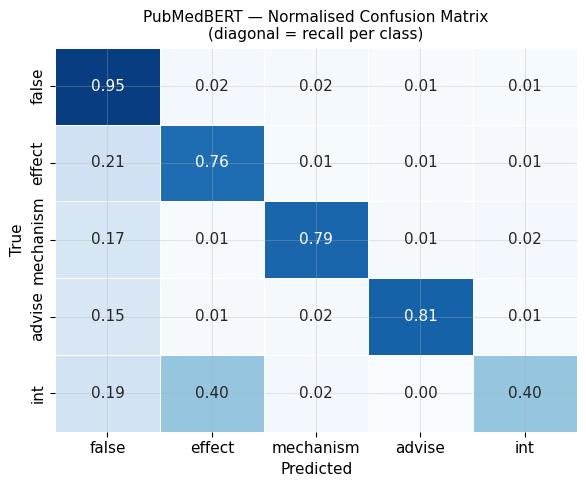

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

cm  = confusion_matrix(y_true, y_pred)
idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]

cm_ord = cm[np.ix_(idx, idx)]

row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1

cm_norm = cm_ord / row_sums

sns.heatmap(
    cm_norm,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER,
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=0.5
)

ax.set_title(
    f'{MODEL_NAME} — Normalised Confusion Matrix\n(diagonal = recall per class)',
    fontsize=11
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(FIG_DIR / 'pubmedbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Class F1 Score Analysis

This section presents the F1 score for each interaction class for the PubMedBERT model, providing a balanced view of precision and recall.

The dashed line indicates the macro-average F1 score, serving as a reference for overall performance. This visualisation helps compare class-wise performance and identify weaker classes that may require further improvement.

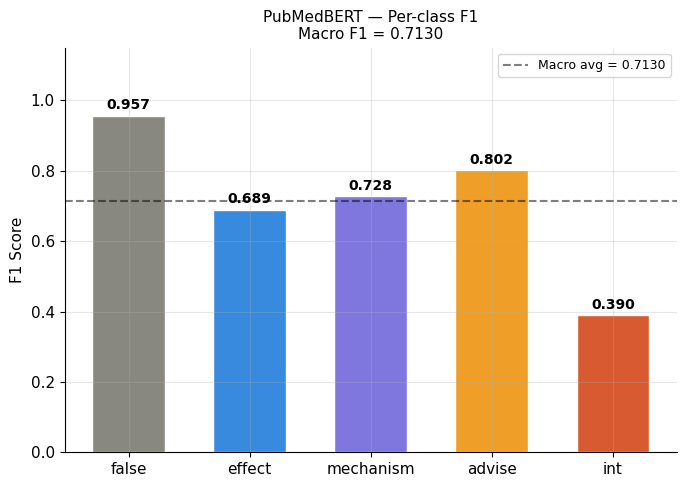

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

rep = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

f1_per_class = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]
cols = [LABEL_COLOURS[l] for l in LABEL_ORDER]

bars = ax.bar(
    LABEL_ORDER,
    f1_per_class,
    color=cols,
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, f1_per_class):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    f'{MODEL_NAME} — Per-class F1\nMacro F1 = {summary["macro_f1"]:.4f}',
    fontsize=11
)

ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)

ax.axhline(
    summary['macro_f1'],
    color='black',
    linestyle='--',
    alpha=0.5,
    label=f'Macro avg = {summary["macro_f1"]:.4f}'
)

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pubmedbert_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Model and Results

This section saves the trained PubMedBERT model, tokenizer, and evaluation outputs. Predictions and ground truth labels are stored for use in later comparison phases.

A results summary is also exported to support benchmarking across different transformer models.

In [10]:
# Save Model and Tokeniser
model.save_pretrained(OUTPUT_DIR)
tokeniser.save_pretrained(OUTPUT_DIR)


# Save Predictions
pred_path = PUBMEDBERT_PREDS_NPY
np.save(pred_path, y_pred)


# Save Ground Truth
gt_path = os.path.join(str(MODELS_DIR / 'shared'), 'y_test.npy')
np.save(gt_path, y_true)

# Save Results CSV
res_path = PUBMEDBERT_RESULTS_CSV
pd.DataFrame([summary]).to_csv(res_path, index=False)


# Save Label Mapping
with open(os.path.join(str(MODELS_DIR / 'shared'), 'label2id.json'), 'w') as f:
    json.dump(LABEL2ID, f)


# Final Summary
print(f'{MODEL_NAME} final Macro F1 : {summary["macro_f1"]:.4f}')
print(f'MCC : {summary["mcc"]:.4f}')
print(f'Balanced Accuracy : {summary["bal_acc"]:.4f}')

PubMedBERT final Macro F1 : 0.7130
MCC : 0.7037
Balanced Accuracy : 0.7403


## Summary

The transformer-based models demonstrate a clear improvement over classical machine learning approaches in capturing complex semantic patterns within biomedical text. By leveraging contextual embeddings, models such as BioBERT and PubMedBERT achieve stronger performance, particularly in distinguishing nuanced interaction types.

The use of class-weighted loss and Macro F1 optimisation ensures that performance is balanced across all classes, rather than being dominated by the majority class. Visual and quantitative evaluations reveal that while overall performance improves, minority classes such as "int" remain challenging due to limited training samples.

Comparative analysis indicates that domain-specific pretraining plays a significant role in performance, with biomedical models outperforming traditional baselines. However, error analysis highlights that certain interaction types are still frequently confused, suggesting opportunities for further improvement through better feature representation or data augmentation.

Overall, this phase validates the effectiveness of transformer-based approaches for DDI detection and establishes a strong foundation for final model comparison and selection in the subsequent phase.